# Day8: 실습을 통해 익히는 생성형AI

## 학습 내용
1. Langchain 사용자도구 호출
2. LangGraph 이해
3. StateGraph 이해
4. LangGragh ReAct agent 활용

## 참고자료
  - LangChain docs: https://docs.langchain.com/
  - 인프런: AI 에이전트로 구현하는 RAG 시스템(판다스 스튜디오)

In [ ]:
!pip install -qU langchain langchain-openai langchain-community langchain-core langgraph wikipedia langchain_chroma
# !pip install langchain-google-genai

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.2/471.2 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.8/20.8 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os, json, re
from IPython.display import Image

import langchain, langchain_core, langchain_community, wikipedia

from langchain_openai import ChatOpenAI
# from langchain_google_genai import ChatGoogleGenerativeAI

from textwrap import dedent
from pprint import pprint

import warnings
warnings.filterwarnings("ignore")

print("langchain version = ", langchain.__version__)
print("langchain core version = ", langchain_core.__version__)
print("langchain community version = ", langchain_community.__version__)
print("langchain community version = ", langchain_community.__version__)
print("wikipedia version = ", wikipedia.__version__)


langchain version =  1.0.5
langchain core version =  1.0.4
langchain community version =  0.4.1
langchain community version =  0.4.1
wikipedia version =  (1, 4, 0)


## API load

In [ ]:
# Set the API key
# os.environ['OPENAI_API_KEY'] = api_key
# os.environ['GOOGLE_API_KEY'] = api_key

from dotenv import load_dotenv
load_dotenv("/content/drive/MyDrive/LangChain_API/.env")

# os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')

True

## LangChain 사용자 도구 호출 (Runnable 객체)
  - **RunnableLambda** 는 **LangChain Expression Language (LCEL)** 에서 사용되는 핵심 구성 요소 중 하나
  - 일반적인 **Python 함수나 람다 함수** 를 가져와서 LangChain의 표준 인터페이스인 Runnable 객체로 변환해주는 역할
  - 파이프 연산자 (|)로 연결된 체인(Chain) 내부에 사용자 정의 로직을 추가할 수 있게 해주는 역활

### Runnable 객체

In [ ]:
## Runnable 객체 예제 1
from langchain_core.runnables import RunnableLambda
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 1. 딕셔너리에서 특정 키의 값을 추출하는 함수 정의
# LangChain 체인에서는 이전 단계의 출력이 'RunnableLambda'의 단일 인수로 전달됩니다.
def extract_topic(input_dict: dict) -> str:
    # 입력 딕셔너리에서 'user_question' 키의 값을 추출합니다.
    return input_dict.get("user_question")

# 2. RunnableLambda로 래핑
topic_extractor = RunnableLambda(extract_topic)

# 3. 사용 예시 (프롬프트 구성)
template = "당신은 {topic} 전문가입니다. 이 주제에 대해 흥미로운 사실 3가지를 알려주세요."
prompt = ChatPromptTemplate.from_template(template)

# 4. 체인 구성 및 실행
input_data = {"user_question": "우주"} #

# 추출기(extractor)가 딕셔너리에서 '우주'를 추출하고, 프롬프트가 이를 'topic' 변수로 사용합니다.
prompt_runnable  = topic_extractor | prompt # Chain 각 단계별로 연산 후 결과 값을 다음 Chain에 전달. Runnable 객체는 전달만하고 사라진다.
final_prompt = prompt_runnable.invoke(input_data)

In [ ]:
display("final_prompt", final_prompt)

'final_prompt'

ChatPromptValue(messages=[HumanMessage(content='당신은 우주 전문가입니다. 이 주제에 대해 흥미로운 사실 3가지를 알려주세요.', additional_kwargs={}, response_metadata={})])

In [ ]:
# 추출기(extractor)가 딕셔너리에서 '우주'를 추출하고, 프롬프트가 이를 'topic' 변수로 사용합니다.
chat_model = ChatOpenAI(model="gpt-4o-mini")  # $0.15 / $0.6
output_parser = StrOutputParser()
prompt_runnable_chain  = topic_extractor | prompt | chat_model | output_parser
final_prompt = prompt_runnable_chain.invoke(input_data)


In [ ]:
final_prompt

'물론입니다! 우주에 관한 흥미로운 사실 세 가지를 소개하겠습니다.\n\n1. **무중력과 시간의 흐름**: 우주에서는 중력이 매우 낮기 때문에 무중력 상태가 발생합니다. 이로 인해 우주 비행사들은 지구에서보다 더 느리게 노화된다고 알려져 있습니다. 이론적으로, 우주 비행사가 수개월을 우주에서 보낸 후 지구로 돌아오면, 그들에게는 시간이 늦게 지나간 것 같은 경험을 하게 됩니다. 이는 아인슈타인의 일반 상대성 이론에 따른 것으로, 중력이 강한 곳에서 시간이 더 느리게 흐릅니다.\n\n2. **우주의 크기와 팽창**: 우주는 계속해서 팽창하고 있습니다. 대폭발 이론에 따르면, 우주는 약 138억 년 전에 시작되었으며, 지금도 계속해서 팽창하고 있다고 합니다. 이러한 팽창 속도는 허블 상수를 통해 측정되며, 이는 먼 은하가 우리로부터 멀어질수록 그 속도가 빨라진다는 것을 나타냅니다. 최근 연구에 따르면, 이 팽창 속도는 점점 빨라지고 있다는 사실도 밝혀졌습니다.\n\n3. **퀀텀 얽힘과 우주**: 양자 역학의 한 현상인 퀀텀 얽힘은 두 개 이상의 입자가 서로 멀리 떨어져 있어도 서로의 상태에 즉각적으로 영향을 미칠 수 있는 현상입니다. 이 개념은 우주에서도 적용될 수 있으며, 이는 우주의 기원이나 블랙홀과 같은 극한 상황에서 중요한 역할을 할 수 있는 것으로 여겨집니다. 이러한 얽힘 현상은 양자 통신과 컴퓨터 등의 첨단 기술에도 응용될 가능성이 있습니다.\n\n이처럼 우주는 신비하고 흥미로운 여러 가지 현상들로 가득 차 있습니다!'

In [ ]:
## Runnable 객체 예제 2
# 수정된 함수: 여러 키/값을 포함하는 딕셔너리를 반환
def extract_context(input_dict: dict) -> dict:
    # 딕셔너리 형태로 반환하며, 템플릿에 필요한 모든 변수를 포함
    return {
        "topic": input_dict.get("user_question"), # 기존 변수
        "level": input_dict.get("level")          # 추가 변수
    }

# 2. RunnableLambda로 래핑
context_extractor = RunnableLambda(extract_context)

# 3. 수정된 프롬프트 구성 (추가 변수 {level} 포함)
template_with_level = "당신은 {topic} 전문가입니다. 내용을 {level} 수준으로 이 주제에 대해 흥미로운 사실 3가지를 알려주세요."
prompt_with_level = ChatPromptTemplate.from_template(template_with_level)

# 4. 체인 구성 및 실행
input_data = {"user_question": "우주", "level": "고급"}

# 추출기가 {"topic": "우주", "level": "고급"} 딕셔너리를 반환합니다.
# 이 딕셔너리의 키/값이 prompt의 변수와 매핑됩니다.
prompt_runnable = context_extractor | prompt_with_level
final_prompt = prompt_runnable.invoke(input_data)

In [ ]:
print("final_prompt = ", final_prompt.messages[0].content)

final_prompt =  당신은 우주 전문가입니다. 내용을 고급 수준으로 이 주제에 대해 흥미로운 사실 3가지를 알려주세요.


### RunnablePassthrough 객체

In [ ]:
## RunnablePassthrough 객체 예제 1
from langchain_core.runnables import RunnableLambda
from langchain_core.messages import HumanMessage
from langchain_core.runnables import RunnablePassthrough

# 1. 모델 응답을 후처리하는 함수 정의
def check_and_append_ending(output_dict: dict) -> str:
    # 응답이 '요.'로 끝나지 않으면 추가합니다.
    if output_dict["content"].endswith("요"):
        output_dict["content"] += " (응답 끝 확인 완료)"
    return f"{output_dict["input"]}: {output_dict["content"]}"

# 2. RunnableLambda로 래핑
response_checker = RunnableLambda(check_and_append_ending)

# 3. 가상 체인 구성
# 원래의 입력 맵을 유지하면서 새로운 키를 추가
fake_model_step = RunnablePassthrough.assign(
    content=lambda x: "좋은 하루 되세요"
)

# 4. 체인 구성 및 실행
# fake_model_step의 출력이 response_checker로 전달됩니다.

chain = fake_model_step | response_checker

final_result = chain.invoke({"input": "아침 인사"}) # 'dummy' 입력은 사용되지 않지만 구조를 위해 필요합니다.

display("chain = ",chain)
print(final_result)

'chain = '

RunnableAssign(mapper={
  content: RunnableLambda(lambda x: '좋은 하루 되세요')
})
| RunnableLambda(check_and_append_ending)

아침 인사: 좋은 하루 되세요 (응답 끝 확인 완료)


In [ ]:
## RunnablePassthrough 객체 예제 2
def get_weather(context):
    """입력된 이름에 따라 다른 날씨를 반환하는 함수"""
    name = context.get("name")

    if "제미나이" in name:
        return "🔥 쾌청하고 따뜻한 날씨"
    elif "코딩" in name:
        return "⛈️ 폭풍우가 몰아치는 날씨"
    else:
        return "☁️ 구름이 많고 선선한 날씨"

# RunnableLambda로 변환
weather_runnable = RunnableLambda(get_weather)

In [ ]:
# ⭐️ 핵심 체인 ⭐️
weather_chain = (
    # 1. 초기 입력을 그대로 다음 단계로 전달
    RunnablePassthrough().assign(weather=weather_runnable)
    | RunnableLambda(lambda x: f"안녕하세요, {x['name']}님! 오늘은 {x['weather']}입니다.")
)

In [ ]:
# 💡 예제 1: 일반 사용자
input_1 = {"name": "김철수"}
result_1 = weather_chain.invoke(input_1)
print(f"**[입력]:** {input_1}")
print(f"**[결과]:** {result_1}\n")

# 💡 예제 2: 특별한 이름 ('제미나이')
input_2 = {"name": "제미나이"}
result_2 = weather_chain.invoke(input_2)
print(f"**[입력]:** {input_2}")
print(f"**[결과]:** {result_2}\n")

# 💡 예제 3: '코딩'이 포함된 이름
input_3 = {"name": "코딩 신동"}
result_3 = weather_chain.invoke(input_3)
print(f"**[입력]:** {input_3}")
print(f"**[결과]:** {result_3}\n")

**[입력]:** {'name': '김철수'}
**[결과]:** 안녕하세요, 김철수님! 오늘은 ☁️ 구름이 많고 선선한 날씨입니다.

**[입력]:** {'name': '제미나이'}
**[결과]:** 안녕하세요, 제미나이님! 오늘은 🔥 쾌청하고 따뜻한 날씨입니다.

**[입력]:** {'name': '코딩 신동'}
**[결과]:** 안녕하세요, 코딩 신동님! 오늘은 ⛈️ 폭풍우가 몰아치는 날씨입니다.



### Pydantic BaseModel 사용법

In [ ]:
# 객체 생성 시 데이터의 유효성을 검사하고, 데이터를 다양한 형식으로 변환하는 것
# Python의 타입 힌트를 활용하여 런타임에 데이터가 원하는 스키마와 형식을 따르는지 보장해주는 라이브러리
from pydantic import BaseModel, ValidationError

class User(BaseModel):
    user_id: int
    name: str
    is_active: bool

# 딕셔너리를 사용하여 객체 생성
user_data = {
    "user_id": 1,
    "name": "Alice Kim",
    "is_active": True
}

try:
    user1 = User(**user_data)
    print("--- 1. 객체 생성 성공 ---")
    display(user1)
    print(f"ID: {user1.user_id}, 타입: {type(user1.user_id)}")

except ValidationError as e:
    print(f"오류 발생: {e.errors()}")

--- 1. 객체 생성 성공 ---


User(user_id=1, name='Alice Kim', is_active=True)

ID: 1, 타입: <class 'int'>


In [ ]:
# 'user_id'에 문자열, 'is_active'에 숫자를 전달
invalid_data = {
    "user_id": "one hundred",  # str (int로 강제 변환 불가능)
    "name": "Bob Park",
    "is_active": 1            # int (bool로 강제 변환 가능)
}

print("\n--- 2. 유효성 검사 실패 시도 ---")

try:
    # 'user_id'에서 오류가 발생하고 객체 생성에 실패
    user2 = User(**invalid_data)
    print(user2)

except ValidationError as e:
    print("유효성 검사 실패 (ValidationError 발생):")
    # 오류 메시지는 어떤 필드에서 어떤 문제가 발생했는지 상세히 보여줍니다.
    print(e.errors())


--- 2. 유효성 검사 실패 시도 ---
유효성 검사 실패 (ValidationError 발생):
[{'type': 'int_parsing', 'loc': ('user_id',), 'msg': 'Input should be a valid integer, unable to parse string as an integer', 'input': 'one hundred', 'url': 'https://errors.pydantic.dev/2.11/v/int_parsing'}]


### Wikipedia runnable 개체

In [ ]:
from pydantic import BaseModel, Field
from langchain_community.document_loaders import WikipediaLoader
from langchain_community.tools import TavilySearchResults
from langchain_core.documents import Document
from langchain_core.runnables import RunnableLambda

search_web = TavilySearchResults(max_results=2)

# WikipediaLoader를 사용하여 위키피디아 문서를 검색하는 함수
def search_wiki(input_data: dict) -> list[Document]:
    """Search Wikipedia documents based on user input (query) and return k documents"""
    query = input_data["query"]
    k = input_data.get("k", 2)
    wiki_loader = WikipediaLoader(query=query, load_max_docs=k, lang="ko")
    wiki_docs = wiki_loader.load()
    return wiki_docs

# 도구 호출에 사용할 입력 스키마 정의
class WikiSearchSchema(BaseModel):
    """Input schema for Wikipedia search."""
    query: str = Field(..., description="The query to search for in Wikipedia")
    k: int = Field(2, description="The number of documents to return (default is 2)")

# RunnableLambda 함수를 사용하여 위키피디아 문서 로더를 Runnable로 변환
# .as_tool : 어떤 Runnable 객체든지 OpenAI 스타일의 Function Calling/Tool Calling에 사용할 수 있는 Tool 객체로 변환
runnable = RunnableLambda(search_wiki)
wiki_search = runnable.as_tool(
    name="wiki_search",
    description=dedent("""
        Use this tool when you need to search for information on Wikipedia.
        It searches for Wikipedia articles related to the user's query and returns
        a specified number of documents. This tool is useful when general knowledge
        or background information is required.
    """),
    args_schema=WikiSearchSchema
)

wiki_search

StructuredTool(name='wiki_search', description="Use this tool when you need to search for information on Wikipedia.\nIt searches for Wikipedia articles related to the user's query and returns\na specified number of documents. This tool is useful when general knowledge\nor background information is required.", args_schema=<class '__main__.WikiSearchSchema'>, func=<function convert_runnable_to_tool.<locals>.invoke_wrapper at 0x7efe99d1ba60>, coroutine=<function convert_runnable_to_tool.<locals>.ainvoke_wrapper at 0x7efe99d1bb00>)

In [ ]:
# 도구 속성
print("자료형: ")
print(type(wiki_search))
print("-"*100)

print("name: ")
print(wiki_search.name)
print("-"*100)

print("description: ")
pprint(wiki_search.description)
print("-"*100)

print("schema: ")
pprint(wiki_search.args_schema.schema())
print("-"*100)

자료형: 
<class 'langchain_core.tools.structured.StructuredTool'>
----------------------------------------------------------------------------------------------------
name: 
wiki_search
----------------------------------------------------------------------------------------------------
description: 
('Use this tool when you need to search for information on Wikipedia.\n'
 "It searches for Wikipedia articles related to the user's query and returns\n"
 'a specified number of documents. This tool is useful when general knowledge\n'
 'or background information is required.')
----------------------------------------------------------------------------------------------------
schema: 
{'description': 'Input schema for Wikipedia search.',
 'properties': {'k': {'default': 2,
                      'description': 'The number of documents to return '
                                     '(default is 2)',
                      'title': 'K',
                      'type': 'integer'},
                'q

In [ ]:
# 위키 검색 실행
query = "깍두기의 유래"
wiki_results = wiki_search.invoke({"query":query})

# 검색 결과 출력
for result in wiki_results:
    print(result)
    print("-" * 100)

page_content='깍두기는 한국인에게 배추김치와 더불어 가장 인기있는 김치이자 반찬으로 '깍둑썰다'는 단어에서 유래했다. 젓무·홍저(紅葅)라고도 부르며, 궁중에서는 송송이라고도 하였다. 무를 육면체 모양으로 작게 썰어 소금에 절인후 고추와 마늘 등 양념해 만드는 김치의 하나로, 무가 배추를 대신했다는 점만 다르고 일반적인 배추김치를 담글 때 사용하는 재료가 다 들어간다. 
1940년에 발간된 《조선요리학》에서 깍두기는 정조의 딸 숙선옹주가 만들어 바치면서 유래다. 당시 종친 어르신들이 "어떻게 만들었느냐"고 묻자 숙선옹주가 "평소 남는 무를 '깍둑깍둑' 썰어서 버무렸더니 맛이 있어서 이번에 내놓게 됐습니다"라고 해서 깍두기로 불리게 됐다고 한다. 깍두기를 음차해서 '각독기(刻毒氣)'로 표기하면서 독기를 없애는 음식으로 알려지기도 했다. 
공주로 낙향한 한 정승이 깍두기를 민간에 퍼뜨리며 '공주깍두기'라고 알려졌다는 이야기도 있다. 공주시에서는 '공주깍두기' 유래를 알리고자 매 해 공주 깍두기 축제를 개최하고 있다.  
영조·정조시대 작품 《춘형전》에 깍두기가 등장하는데 "어사또 상을 보니 어찌 아니 통분하랴. 떨어진 개상판에 콩나물 깍대기 막걸리 한사발 놓았구나." 라는 구절이 있다. 1800년대 말 쓰인것으로 추정되는 조선시대 조리서 《시의전서》(是議全書)에도 젓무라는 명칭으로 깍두기 조리법이 기록되어 있으며, 1913년 《요리제법》(料理製法)에는 깍두기를 비롯하여 오이깍두기, 굴깍두기, 숙깍두기, 닭깍두기 등 다양한 종류의 조리법이 적혀있다. 


== 담그는 방법 ==
깍두기를 담그려면, 먼저 무를 작은 장방형으로 깍둑썰기하고, 소금과 고춧가루, 파, 생강 등으로 간을 한다. 무와 다른 재료를 서로 섞은 후에, 장독이나 서늘하고 건조한 곳에서 약 2주 동안 발효시킨다.
깍두기는 차갑게 해서 먹고, 일반적으로 무가 너무 무르기 전에 아삭아삭할 때 먹는다. 깍두기는 다른 종류의 김치와 함께 한국에서 인기가 있으며, 발효해서 생기는 김치류의 영양을 공통

### LLM에 도구를 바인딩 (2개의 도구 바인딩)

In [ ]:
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools=[search_web, wiki_search])

# 도구 호출이 필요한 LLM 호출을 수행
query = "깍두기의 유래를 알려주세요. 유명한 칼국수 맛집은 어디인가요? "
ai_msg = llm_with_tools.invoke(query)

# LLM의 전체 출력 결과 출력
display("ai_msg = ", ai_msg)
print("-" * 100)

# 메시지 content 속성 (텍스트 출력)
display("ai_msg.content = ", ai_msg.content)
print("-" * 100)

# LLM이 호출한 도구 정보 출력
display("ai_msg.tool_calls = ", ai_msg.tool_calls)
print("-" * 100)

'ai_msg = '

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 196, 'total_tokens': 260, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-CbQLNLxuS3ODr9YwDMsymJE4OpPFd', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--b7bba9f9-94dd-4e51-ab1c-af83ba20553c-0', tool_calls=[{'name': 'wiki_search', 'args': {'query': '깍두기', 'k': 1}, 'id': 'call_eE2Ve5AepjCFRnHPSxGLqZgr', 'type': 'tool_call'}, {'name': 'tavily_search_results_json', 'args': {'query': '유명한 칼국수 맛집'}, 'id': 'call_P2IB2GzjC4voYfm7K3s6PZmg', 'type': 'tool_call'}], usage_metadata={'input_tokens': 196, 'output_tokens': 64, 'total_tokens': 260, 'in

----------------------------------------------------------------------------------------------------


'ai_msg.content = '

''

----------------------------------------------------------------------------------------------------


'ai_msg.tool_calls = '

[{'name': 'wiki_search',
  'args': {'query': '깍두기', 'k': 1},
  'id': 'call_eE2Ve5AepjCFRnHPSxGLqZgr',
  'type': 'tool_call'},
 {'name': 'tavily_search_results_json',
  'args': {'query': '유명한 칼국수 맛집'},
  'id': 'call_P2IB2GzjC4voYfm7K3s6PZmg',
  'type': 'tool_call'}]

----------------------------------------------------------------------------------------------------


In [ ]:
## Runable 개체
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda
from langchain_community.document_loaders import WikipediaLoader

# WikipediaLoader를 사용하여 위키피디아 문서를 검색하고 텍스트로 반환하는 함수
def wiki_search_and_summarize(input_data: dict):
    wiki_loader = WikipediaLoader(query=input_data["query"], load_max_docs=2, lang="ko")
    wiki_docs = wiki_loader.load()

    formatted_docs =[
        f'<Document source="{doc.metadata["source"]}"/>\n{doc.page_content}\n</Document>'
        for doc in wiki_docs
        ]

    return formatted_docs

# 요약 프롬프트 템플릿
summary_prompt = ChatPromptTemplate.from_template(
    "Summarize the following text in a concise manner:\n\n{context}\n\nSummary:"
)

# LLM 및 요약 체인 설정
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
summary_chain = (
    {"context": RunnableLambda(wiki_search_and_summarize)}
    | summary_prompt | llm | StrOutputParser()
)

# 요약 테스트
summarized_text = summary_chain.invoke({"query":"깍두기의 유래"})
display(summarized_text)

"깍두기는 한국의 인기 있는 김치로, 무를 육면체로 썰어 소금에 절인 후 고추와 마늘 등으로 양념하여 만든다. 1940년 발간된 《조선요리학》에 따르면, 깍두기는 정조의 딸 숙선옹주가 남는 무를 썰어 맛있게 만들어 유래되었다. 깍두기는 보통 차갑게 먹으며, 아삭한 식감이 특징이다. 다양한 변형이 있으며, 공주에서는 '공주깍두기' 축제를 개최한다. \n\n궁바오지딩은 중국의 닭고기 요리로, 땅콩과 고추, 채소를 볶아 만든다. 이 요리는 청나라 시절 정보정이 손님에게 대접하던 요리에서 유래되었으며, 매운맛이 특징이다. 궁바오지딩은 닭고기를 깍두기 모양으로 썰어 만든 요리로, 쓰촨에서 인기를 끌었다."

## LangGraph

- 대규모 언어 모델(LLM)을 사용하여 복잡하고 상태를 유지하는 다중 에이전트 애플리케이션을 구축하기 위한 워크플로우 프레임워크
- 그래프 구조와 상태 머신을 기반으로 하며, 에이전트 간의 반복, 분기, 복잡한 상태 관리가 가능
- LangChain의 기능을 확장하여, 더 유연하고 제어 가능한 방식으로 복잡한 AI 애플리케이션을 만들 수 있게 함
- 조건부 기반 분기 또는 이전 노드로 회귀가 가능해 일직선으로 수행하는 LangChain 대비 높은 자유도

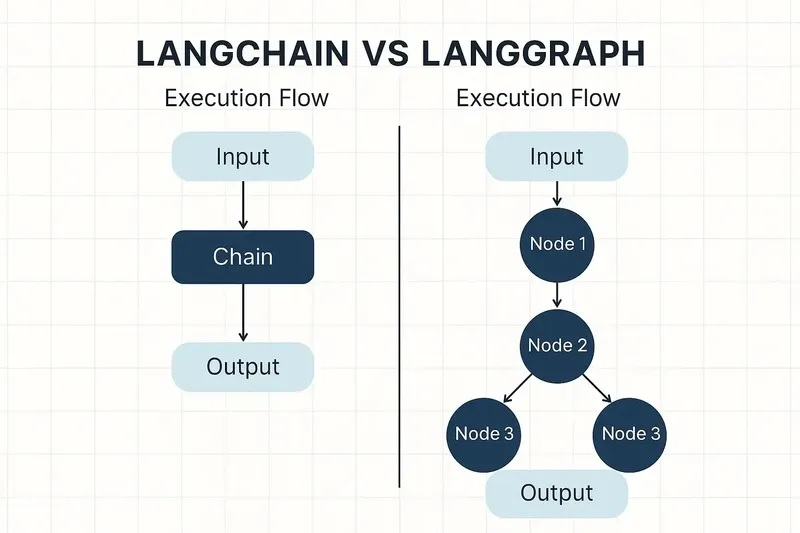

In [ ]:
# Image(os.path.join(os.getcwd(), 'LangGraph.jpg'))

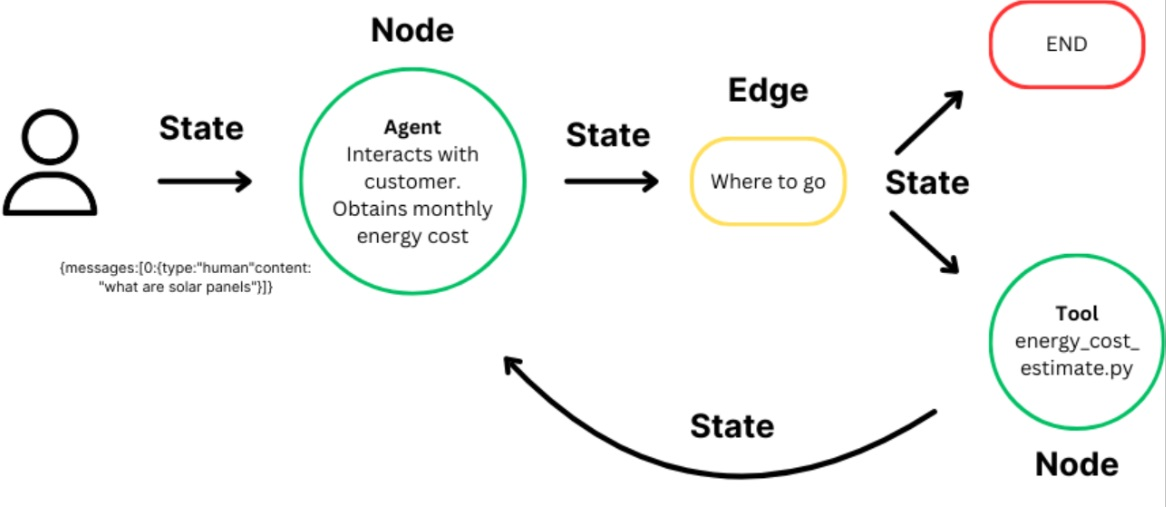

In [ ]:
# Image(os.path.join(os.getcwd(), 'state_node_edge.jpg'))

### LangGraph 구성 예제 1

In [ ]:
from langgraph.graph import StateGraph, START, END

# 상태 정의를 위한 필수 임포트
from typing import TypedDict

# 상태 정의 (노드 간에 전달될 데이터 구조)
class SimpleState(TypedDict):
    output: str # 'output' 키에 값 타입 정의

# 1. 노드로 사용할 함수 정의 (각 단계에서 수행할 작업)
def node_1(input_state: SimpleState):
    """입력 문자열에 첫 번째 메시지를 추가합니다."""
    # input_state.get("output", "") 대신 상태 키를 직접 사용
    return {"output": input_state["output"] + " -> node_1 : 데이터 로드 완료."}

def node_2(input_state: SimpleState):
    """이전 단계 결과에 두 번째 메시지를 추가합니다."""
    return {"output": input_state["output"] + " -> node_2:  전처리 완료."}

# 2. 그래프 객체 생성
workflow = StateGraph(SimpleState) # StateGraph에 상태 정의를 전달

# 3. 노드 추가
workflow.add_node("node_1", node_1)
workflow.add_node("node_2", node_2)

# 4. 시작점과 끝점 설정
# 엣지(흐름) 정의 (node_1 -> node_2)
workflow.add_edge(START, "node_1")
workflow.add_edge("node_1", "node_2")
workflow.add_edge("node_2", END)

# 5. 그래프 컴파일
app = workflow.compile()

# 6. 실행
initial_state = {"output": "시작"}
result = app.invoke(initial_state)

print(f"초기 상태: {initial_state['output']}")
print(f"최종 결과: {result['output']}")

초기 상태: 시작
최종 결과: 시작 -> node_1 : 데이터 로드 완료. -> node_2:  전처리 완료.


### LangGraph 구성 예제 2

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

# 1. 상태 정의 (문자열과 정수를 포함)
class PipelineState(TypedDict):
    """
    data_str: 주요 처리 대상 문자열 데이터
    process_count: 현재까지 처리된 횟수 (정수)
    """
    data_str: str
    process_count: int

# 2. 노드 함수 정의 (각 단계에서 수행할 작업)

def node_1_init(input_state: PipelineState) -> dict:
    """
    데이터를 초기화하고 처리 횟수를 1 증가시킵니다.
    """
    current_count = input_state["process_count"]

    # 정수 값 업데이트 및 로그 기록
    new_count = current_count + 1
    new_data_str = input_state["data_str"] + " | (node_1: 초기화 완료)"

    print(f"-> Node 1: 처리 횟수 {current_count} -> {new_count} (data_str 업데이트)")
    # data_str과 process_count 모두 반환
    return {"data_str": new_data_str, "process_count": new_count}

def node_2_transform(input_state: PipelineState) -> dict:
    """
    데이터 문자열을 변환(대문자)하고 처리 횟수를 1 증가시킵니다.
    """
    current_count = input_state["process_count"]
    current_data = input_state["data_str"]

    # 정수 값 및 문자열 값 업데이트
    new_count = current_count + 1
    new_data_str = current_data.upper() + " | (node_2: 대문자 변환 완료)"

    print(f"-> Node 2: 처리 횟수 {current_count} -> {new_count} (data_str 업데이트)")
    # data_str과 process_count 모두 반환
    return {"data_str": new_data_str, "process_count": new_count}

# 3. 그래프 객체 생성
workflow = StateGraph(PipelineState)

# 4. 노드 추가
workflow.add_node("node_1", node_1_init)
workflow.add_node("node_2", node_2_transform)

# 5. 엣지(흐름) 정의 및 시작/종료점 설정
# START -> init_data -> transform_data -> END
workflow.add_edge(START, "node_1")
workflow.add_edge("node_1", "node_2")
workflow.add_edge("node_2", END)

# 6. 그래프 컴파일
app = workflow.compile()

# 7. 실행
initial_state = {"data_str": "start with small letters", "process_count": 0}
result = app.invoke(initial_state)

print("\n==========================")
print(f"초기 데이터: '{initial_state['data_str']}'")
print(f"최종 데이터: '{result['data_str']}'")
print(f"최종 처리 횟수: {result['process_count']}")

-> Node 1: 처리 횟수 0 -> 1 (data_str 업데이트)
-> Node 2: 처리 횟수 1 -> 2 (data_str 업데이트)

초기 데이터: 'start with small letters'
최종 데이터: 'START WITH SMALL LETTERS | (NODE_1: 초기화 완료) | (NODE_2: 대문자 변환 완료)'
최종 처리 횟수: 2


### LangGraph 구성 예제 3

In [ ]:
from typing import TypedDict
import random

# 상태 Schema 정의 - 사용자의 선호도, 추천된 메뉴, 그리고 메뉴 정보를 저장
class MenuState(TypedDict):
    user_preference: str
    recommended_menu: str
    menu_info: str


def get_user_preference(state: MenuState) -> MenuState:
    print("---랜덤 사용자 선호도 생성---")
    preferences = ["반도체", "2차전지", "해운", "바이오"]
    preference = random.choice(preferences)
    print(f"생성된 선호도: {preference}")
    return {"user_preference": preference}

def recommend_menu(state: MenuState) -> MenuState:
    print("---종목 추천---")
    preference = state['user_preference']
    if preference == "반도체":
        menu = "SK하이닉스"
    elif preference == "2차전지":
        menu = "삼성SDI"
    elif preference == "중장비":
        menu = "HMM"
    else:
        menu = "알테오젠"
    print(f"추천 메뉴: {menu}")
    return {"recommended_menu": menu}

def provide_menu_info(state: MenuState) -> MenuState:
    print("---메뉴 정보 제공---")
    menu = state['recommended_menu']
    if menu == "SK하이닉스":
        info = "대한민국의 메모리 반도체 설계, 제조 기업. 가격: 578,500원"
    elif menu == "삼성SDI":
        info = "에너지 및 소재 전문 글로벌 기업. 가격: 323,000원"
    elif menu == "HMM":
        info = "현대 상선의 영문명. 가격: 19,760원"
    else:
        info = "히알루로니다제를 사용하여 정맥주사제형 치료제를 피하주사제형으로 변경하는 플랫폼. 가격: 529,000원"
    print(f"메뉴 정보: {info}")
    return {"menu_info": info}

In [ ]:
from langgraph.graph import StateGraph, START, END

# 그래프 빌더 생성
builder = StateGraph(MenuState)

# 노드 추가
builder.add_node("get_preference", get_user_preference)
builder.add_node("recommend", recommend_menu)
builder.add_node("provide_info", provide_menu_info)

# 엣지 추가
builder.add_edge(START, "get_preference")
builder.add_edge("get_preference", "recommend")
builder.add_edge("recommend", "provide_info")
builder.add_edge("provide_info", END)

# 그래프 컴파일
graph = builder.compile()

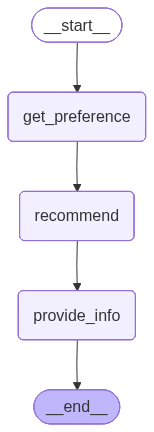

In [ ]:
from IPython.display import Image

# 그래프 시각화
Image(graph.get_graph().draw_mermaid_png())


In [ ]:
# 그래프 실행

def print_result(result: MenuState):
    print("\n=== 결과 ===")
    print("종목:", result['user_preference'])
    print("추천 종목:", result['recommended_menu'])
    print("종목 정보:", result['menu_info'])
    print("============\n")


# 초기 입려
inputs = {"user_preference": ""}

# 여러 번 실행하여 테스트
for _ in range(2):
    result = graph.invoke(inputs)
    print_result(result)
    print("*"*100)
    print()

---랜덤 사용자 선호도 생성---
생성된 선호도: 2차전지
---종목 추천---
추천 메뉴: 삼성SDI
---메뉴 정보 제공---
메뉴 정보: 에너지 및 소재 전문 글로벌 기업. 가격: 323,000원

=== 결과 ===
종목: 2차전지
추천 종목: 삼성SDI
종목 정보: 에너지 및 소재 전문 글로벌 기업. 가격: 323,000원

****************************************************************************************************

---랜덤 사용자 선호도 생성---
생성된 선호도: 2차전지
---종목 추천---
추천 메뉴: 삼성SDI
---메뉴 정보 제공---
메뉴 정보: 에너지 및 소재 전문 글로벌 기업. 가격: 323,000원

=== 결과 ===
종목: 2차전지
추천 종목: 삼성SDI
종목 정보: 에너지 및 소재 전문 글로벌 기업. 가격: 323,000원

****************************************************************************************************



## 조건부 엣지(Edge)

### 조건부 엣지(Edge) 예제 1

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

# 1. 그래프 상태 정의 (operator 없이 순수 TypedDict 사용)
class AgentState(TypedDict):
    """
    노드 간에 전달되는 상태를 정의합니다.
    LangGraph는 기본적으로 노드가 반환하는 딕셔너리를 이전 상태에 병합합니다.
    """
    query: str
    decision: str
    result: str # 최종 결과 저장을 위한 키 추가

# 2. 노드 함수 정의
def agent_node(state: AgentState) -> dict:
    """질문 길이에 따라 다음 단계를 결정하고, 'decision'을 반환합니다."""
    query = state["query"]
    # 상태 딕셔너리를 반환하면, 기존 상태에 이 딕셔너리가 병합됩니다.
    if len(query.split()) > 5:
        decision = "COMPLEX"
        print(f"-> Agent Node: 질문이 길어 '{decision}'으로 결정")
    else:
        decision = "SIMPLE"
        print(f"-> Agent Node: 질문이 짧아 '{decision}'으로 결정")

    return {"decision": decision}

def simple_answer_node(state: AgentState) -> dict:
    """단순 답변 경로의 최종 결과를 'result' 키에 저장합니다."""
    return {"result": f"[SIMPLE PATH] 짧은 질문에 대한 바로 처리된 답변입니다: {state['query']}"}

def complex_process_node(state: AgentState) -> dict:
    """복잡 처리 경로의 최종 결과를 'result' 키에 저장합니다."""
    return {"result": f"[COMPLEX PATH] 긴 질문에 대한 심층 분석이 필요한 답변입니다: {state['query']}"}

# 3. 조건 분기 함수 정의
def route_decision(state: AgentState) -> str:
    """decision 값에 따라 다음 노드를 결정합니다."""
    if state["decision"] == "SIMPLE":
        return "simple_path_node"
    else:
        # decision == "COMPLEX"
        return "complex_path_node"


--- 짧은 질문 실행 ---
-> Agent Node: 질문이 짧아 'SIMPLE'으로 결정
최종 결과: [SIMPLE PATH] 짧은 질문에 대한 바로 처리된 답변입니다: 오늘 날씨 어때?

--- 긴 질문 실행 ---
-> Agent Node: 질문이 길어 'COMPLEX'으로 결정
최종 결과: [COMPLEX PATH] 긴 질문에 대한 심층 분석이 필요한 답변입니다: 이번 주말에 부산에서 열리는 주요 행사에 대해 자세히 알려줄 수 있니?


In [ ]:
# 4. 그래프 생성 및 노드 추가
workflow = StateGraph(AgentState)
workflow.add_node("agent", agent_node)
workflow.add_node("simple_path", simple_answer_node)
workflow.add_node("complex_path", complex_process_node)

# 5. 시작점, 조건부 엣지, 종료점 설정

workflow.add_edge(START, "agent")
workflow.add_conditional_edges(
    "agent",           # 소스 노드 (결정을 내리는 노드)
    route_decision,    # 라우팅 함수
    {                  # 라우팅 함수 결과와 연결할 타겟 노드 매핑
        "simple_path_node": "simple_path",
        "complex_path_node": "complex_path",
    }
)

# 6. 종료점 설정

workflow.add_edge("simple_path", END)
workflow.add_edge("complex_path", END)

# 7. 컴파일
app = workflow.compile()


In [ ]:

# --- 실행 ---

# 짧은 질문 실행
print("--- 짧은 질문 실행 ---")
result_short = app.invoke({"query": "오늘 날씨 어때?"})
print(f"최종 결과: {result_short['result']}\n")

# 긴 질문 실행
print("--- 긴 질문 실행 ---")
result_long = app.invoke({"query": "이번 주말에 부산에서 열리는 주요 행사에 대해 자세히 알려줄 수 있니?"})
print(f"최종 결과: {result_long['result']}")

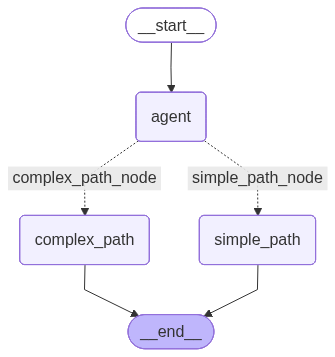

In [ ]:
from IPython.display import Image, display

# 그래프 시각화
Image(app.get_graph().draw_mermaid_png())

### 조건부 엣지(Edge) 예제 2

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

# 1. 상태 정의 (문자열과 정수를 포함)
class ProcessState(TypedDict):
    """
    상태는 재시도 횟수(정수)와 메시지(문자열)를 포함합니다.
    """
    attempts: int # 정수 키: 현재까지의 시도 횟수
    message: str  # 문자열 키: 현재 상태 메시지

# 2. 노드 함수 정의

def node_1_task(state: ProcessState) -> dict:
    """
    주요 작업을 수행하고 실패했다고 가정합니다.
    시도 횟수를 1 증가시키고 메시지를 업데이트합니다.
    """
    current_attempts = state["attempts"]
    new_attempts = current_attempts + 1

    # 작업은 '실패'했다고 가정하고 메시지를 설정합니다.
    new_message = f"시도 #{new_attempts}: 작업 실행 중..."

    print(f"-> Node 1 (Task): 현재 시도 횟수 {new_attempts}")

    return {"attempts": new_attempts, "message": new_message}

def node_2_retry(state: ProcessState) -> dict:
    """
    재시도 전에 상태 메시지를 업데이트합니다.
    """
    new_message = f"시도 #{state['attempts']} 실패. 재시도를 준비합니다."
    print("-> Node 2 (Retry): 다음 시도를 위해 상태 메시지 업데이트.")

    # attempts 키는 그대로 유지하거나 (여기서는 반환하지 않음) 다시 반환할 수 있습니다.
    return {"message": new_message}

def node_3_failure(state: ProcessState) -> dict:
    """
    최대 횟수 초과 시 최종 실패 메시지를 설정합니다.
    """
    final_message = f"최대 시도 횟수({state['attempts']}) 초과! 워크플로우를 종료합니다."
    print("-> Node 3 (Failure): 최대 횟수 초과로 종료 처리.")

    return {"message": final_message}


# 3. 조건 분기 함수 정의
def route_decision(state: ProcessState) -> str:
    """
    현재 시도 횟수에 따라 다음 노드를 결정합니다.
    """
    MAX_ATTEMPTS = random.randint(1,5)

    if state["attempts"] >= MAX_ATTEMPTS:
        # 최대 횟수를 초과했거나 도달하면 실패 경로로
        return "failure_path"
    else:
        # 아직 재시도 기회가 남아있다면 재시도 경로로
        return "retry_path"


In [ ]:

# 4. 그래프 생성 및 노드 추가
workflow = StateGraph(ProcessState)
workflow.add_node("task", node_1_task)
workflow.add_node("retry", node_2_retry)
workflow.add_node("failure_handler", node_3_failure)


# 5. 엣지(흐름) 정의 및 시작/종료점 설정

workflow.add_edge(START, "task")

# 6. 조건부 엣지 정의
# task 노드 완료 후 route_decision 함수를 통해 분기
workflow.add_conditional_edges(
    "task",             # 소스 노드
    route_decision,     # 라우팅 함수
    {                   # 라우팅 함수 결과와 연결할 타겟 노드 매핑
        "failure_path": "failure_handler",
        "retry_path": "retry",
    }
)

# 7. 엣지 연결 (Cycle을 만들어 재시도 구현)
# 재시도 노드에서는 다시 task 노드로 돌아가도록 연결
workflow.add_edge("retry", "task")

# 8. 종료점 설정
workflow.add_edge("failure_handler", END)

# 9. 컴파일
app = workflow.compile()


In [ ]:

# --- 실행 ---

print("--- 재시도 워크플로우 실행 (최대 시도 횟수: 1) ---")
# 초기 상태: 시도 횟수 0
initial_state = {"attempts": 0, "message": "작업 대기 중..."}
result = app.invoke(initial_state)

print("\n**최종 결과:**")
print(f" - 최종 시도 횟수: {result['attempts']}")
print(f" - 최종 메시지: {result['message']}")

--- 재시도 워크플로우 실행 (최대 시도 횟수: 1) ---
-> Node 1 (Task): 현재 시도 횟수 1
-> Node 2 (Retry): 다음 시도를 위해 상태 메시지 업데이트.
-> Node 1 (Task): 현재 시도 횟수 2
-> Node 2 (Retry): 다음 시도를 위해 상태 메시지 업데이트.
-> Node 1 (Task): 현재 시도 횟수 3
-> Node 2 (Retry): 다음 시도를 위해 상태 메시지 업데이트.
-> Node 1 (Task): 현재 시도 횟수 4
-> Node 3 (Failure): 최대 횟수 초과로 종료 처리.

**최종 결과:**
 - 최종 시도 횟수: 4
 - 최종 메시지: 최대 시도 횟수(4) 초과! 워크플로우를 종료합니다.


### 조건부 엣지에 LLM 연결하기

In [ ]:
# state 스키마
class MenuState(TypedDict):
    user_query: str
    is_menu_related: bool
    search_results: list[str]
    final_answer: str

In [ ]:
from langchain_chroma import Chroma
from langchain_ollama  import OllamaEmbeddings

embeddings_model = OllamaEmbeddings(model="bge-m3")

# Chroma 인덱스 로드
vector_db = Chroma(
    embedding_function=embeddings_model,
    collection_name="restaurant_menu",
    persist_directory="./chroma_db",
)

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

# LLM 모델
llm = ChatOpenAI(model="gpt-4o-mini")

def get_user_query(state: MenuState) -> MenuState:
    user_query = input("무엇을 도와드릴까요? ")
    return {"user_query": user_query}

def analyze_input(state: MenuState) -> MenuState:
    analyze_template = """
    사용자의 입력을 분석하여 사내 인사규정에 관한 질문인지 판단하세요.

    사용자 입력: {user_query}

    사내 인사규정이면 "True", 아니면 "False"로 답변하세요.

    답변:
    """
    analyze_prompt = ChatPromptTemplate.from_template(analyze_template)
    analyze_chain = analyze_prompt | llm | StrOutputParser()

    result = analyze_chain.invoke({"user_query": state['user_query']})
    is_menu_related = result.strip().lower() == "true"

    return {"is_menu_related": is_menu_related}

def search_menu_info(state: MenuState) -> MenuState:
    # 벡터저장소에서 최대 2개의 문서를 검색
    # results = vector_db.similarity_search(state['user_query'], k=2)
    search_results = ["사내 매뉴얼을 참조 하세요"]
    return {"search_results": search_results}

def generate_menu_response(state: MenuState) -> MenuState:
    response_template = """
    사용자 입력: {user_query}
    메뉴 관련 검색 결과: {search_results}

    위 정보를 바탕으로 사용자의 메뉴 관련 질문에 대한 상세한 답변을 생성하세요.
    검색 결과의 정보를 활용하여 정확하고 유용한 정보를 제공하세요.

    답변:
    """
    response_prompt = ChatPromptTemplate.from_template(response_template)
    response_chain = response_prompt | llm | StrOutputParser()

    final_answer = response_chain.invoke({"user_query": state['user_query'], "search_results": state['search_results']})
    print(f"\n메뉴 어시스턴트: {final_answer}")

    return {"final_answer": final_answer}

def generate_general_response(state: MenuState) -> MenuState:
    response_template = """
    사용자 입력: {user_query}

    일반적인 대화 맥락에서 적절한 답변을 생성하세요.

    답변:
    """
    response_prompt = ChatPromptTemplate.from_template(response_template)
    response_chain = response_prompt | llm | StrOutputParser()

    final_answer = response_chain.invoke({"user_query": state['user_query']})
    print(f"\n일반 어시스턴트: {final_answer}")

    return {"final_answer": final_answer}

In [ ]:
from typing import Literal

def decide_next_step(state: MenuState) -> Literal["search_menu_info", "generate_general_response"]:
    if state['is_menu_related']:
        return "search_menu_info"
    else:
        return "generate_general_response"

In [ ]:
from langgraph.graph import StateGraph, START, END

# 그래프 구성
builder = StateGraph(MenuState)

# 노드 추가
builder.add_node("get_user_query", get_user_query)
builder.add_node("analyze_input", analyze_input)
builder.add_node("search_menu_info", search_menu_info)
builder.add_node("generate_menu_response", generate_menu_response)
builder.add_node("generate_general_response", generate_general_response)

# 엣지 추가
builder.add_edge(START, "get_user_query")
builder.add_edge("get_user_query", "analyze_input")

# 조건부 엣지 추가
builder.add_conditional_edges(
    "analyze_input",
    decide_next_step,
    {
        "search_menu_info": "search_menu_info",
        "generate_general_response": "generate_general_response"
    }
)

builder.add_edge("search_menu_info", "generate_menu_response")
builder.add_edge("generate_menu_response", END)
builder.add_edge("generate_general_response", END)

# 그래프 컴파일
graph = builder.compile()

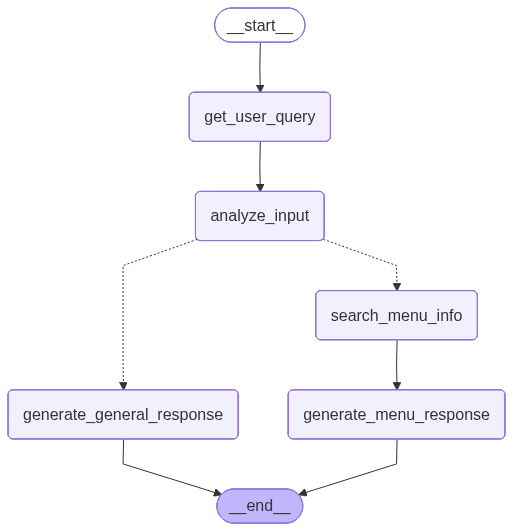

In [ ]:
from IPython.display import Image, display

# 그래프 시각화
Image(graph.get_graph().draw_mermaid_png())

In [ ]:
while True:
    initial_state = {'user_query':''}
    graph.invoke(initial_state)
    continue_chat = input("다른 질문이 있으신가요? (y/n): ").lower()
    if continue_chat != 'y':
        print("대화를 종료합니다. 감사합니다!")
        break

무엇을 도와드릴까요? 사내 인사규정이 궁금합니다

메뉴 어시스턴트: 사내 인사규정에 대한 궁금증을 해결하기 위해서는 사내 매뉴얼을 참조하는 것이 가장 좋습니다. 매뉴얼에는 인사 규정, 정책, 절차 등에 대한 자세한 정보가 포함되어 있어 유용합니다. 매뉴얼을 통해 근무 시간, 복리후생, 연차 사용 규정 등 다양한 인사 관련 사항을 확인할 수 있습니다. 필요한 경우 인사팀에 직접 문의하시면 더욱 구체적인 정보를 얻으실 수 있습니다.
다른 질문이 있으신가요? (y/n): y
무엇을 도와드릴까요? 한우 소고기 등급에 대해서 알려주세요

일반 어시스턴트: 한우 소고기는 품질과 육즙, 식감을 기준으로 여러 등급으로 분류됩니다. 대한민국에서는 주로 1++급, 1+급, 1급, 2급, 3급으로 나뉘며, 숫자가 낮을수록 더 높은 품질을 의미합니다.

1. **1++급**: 최상급으로, 대리석 무늬(마블링)가 아주 좋고 육질이 매우 부드럽습니다. 고급 레스토랑이나 특별한 날에 주로 사용됩니다.
2. **1+급**: 1++급보다 약간 떨어지지만 여전히 높은 품질을 유지합니다. 마블링이 좋고 육즙이 풍부합니다.
3. **1급**: 좋은 품질로, 마블링과 육질이 상대적으로 양호하며 다양한 요리에 적합합니다.
4. **2급**: 품질은 다소 낮지만, 여전히 일반적인 소고기보다 좋습니다. 주로 일상적인 요리에 사용됩니다.
5. **3급**: 가장 낮은 등급으로, 맛과 질감이 떨어지며 가공식품이나 저렴한 요리에 주로 사용됩니다.

한우를 구매할 때는 이러한 등급을 참고하여 자신의 용도와 예산에 맞는 것을 선택하는 것이 좋습니다.
다른 질문이 있으신가요? (y/n): n
대화를 종료합니다. 감사합니다!
